In [1]:
import torch
import os
import sys
from torchvision import transforms

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from preprocessing.load_datasets import load_ucsd_ped2
from preprocessing.sequence_dataset import VideoSequenceDataset

In [2]:
DATA_ROOT = "../data/UCSD_Anomaly_Dataset/UCSD_Anomaly_Dataset.v1p2"

train_videos, _ = load_ucsd_ped2(DATA_ROOT)
print("Train videos:", len(train_videos))


Train videos: 16


In [3]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])


In [5]:
sequence_length = 8

dataset = VideoSequenceDataset(
    train_videos,
    sequence_length=sequence_length,
    transform=transform
)
print("Number of sequences in dataset:", len(dataset))


Total sequences created: 2438
Number of sequences in dataset: 2438


In [6]:
sample = dataset[0]

print("Sequence shape:", sample.shape)
print("Frame pixel range:", sample.min().item(), "to", sample.max().item())

Sequence shape: torch.Size([8, 3, 128, 128])
Frame pixel range: 0.1568627506494522 to 0.7333333492279053


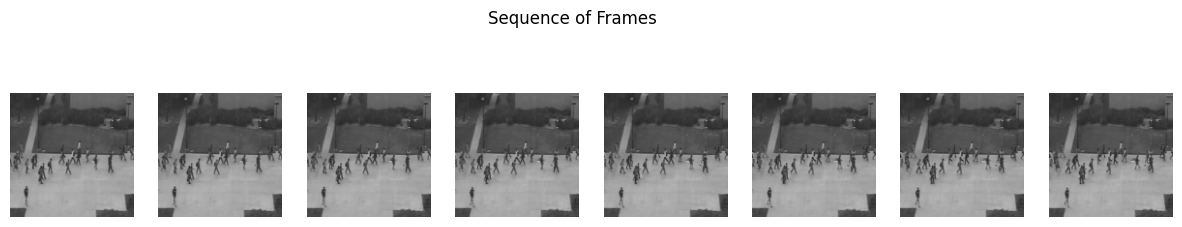

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, sequence_length, figsize=(15,3))

for i in range(sequence_length):
    axes[i].imshow(sample[i].permute(1, 2, 0))
    axes[i].axis("off")

plt.suptitle("Sequence of Frames")
plt.show()
